### Objective:

**Given the dataset, build a predictive model that can help identify the premium quality wines.**

### Data Description:

- `fixed acidity`: Fixed Acidity impart sourness and resist microbial infection, measured in no. of grams of tartaric acid per dm3
- `volatile acidity`: No. of grams of acetic acid per dm3 of wine. Too high levels can lead to an unpleasant, vinegar-like taste
- `citric acid`: No. of grams of citric acid per dm3 of wine. Citric acid can add freshness and flavor to wines
- `residual sugar`: Remaining sugar after fermentation stops, measured in no. of grams per dm3.
- `chlorides`: No. of grams of sodium chloride i.e. salt per dm3 of wine
- `free sulfur dioxide`: No. of grams of free sulfite per dm3 of wine
- `total sulfur dioxide`: No. of grams of total sulfite (free sulphite+ bound) per dm3 of wine
- `density`: Density in gram per cm3
- `pH`: Describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic). The pH of the wine can help measure the ripeness of the wine
- `sulphates`: No. of grams of potassium sulfate per dm3 of wine
- `alcohol`: Volume of alcohol in percentage 
- `quality`: Wine quality score between 3 to 8

#### Import Libraries

In [1]:
# Library to suppress warnings or deprecation notes 
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Libraries to split data, impute missing values 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

# Libtune to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

### Dataset Load and Overview

In [2]:
wine = pd.read_csv('data/28_winequality.csv',sep=';')

In [3]:
# copying data to another varaible to avoid any changes to original data
data = wine.copy()

#### Overview

In [4]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
data.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [6]:
data.shape

(1599, 12)

* There are 1,599 observations and 12 columns in the dataset

In [7]:
# check datatype
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


**Observations-**
* All features are numeric types.
* There are no missing values in the data.

#### Statistical Summary

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


**Observations-**
* *The maximum rating of wine is 8 and the third quartile value is 6 i.e. at least 75% of wines have a rating of 6 or below.*
* *Most wines are on a pH scale between 3 and 4.*

### Exploratory Data Analysis

#### Univariate analysis

**Helper Function**

In [9]:
def num_analysis_hist_box(data, feature, figsize=(10, 5)):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)  # creating the 2 subplots
    
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="lightgreen")  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, color='skyblue')  # For histogram
    
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

#### Observations on fixed acidity

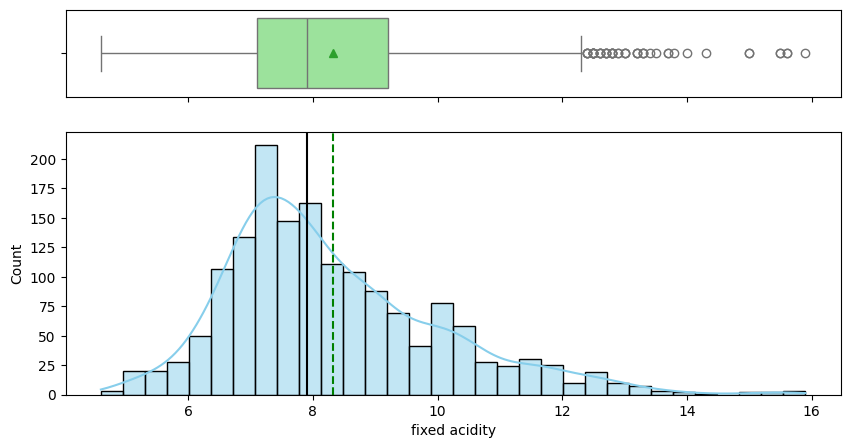

In [10]:
num_analysis_hist_box(data,'fixed acidity')

- *The distribution is nearly symmetric with some outliers to the right.*

#### Observations on volatile acidity

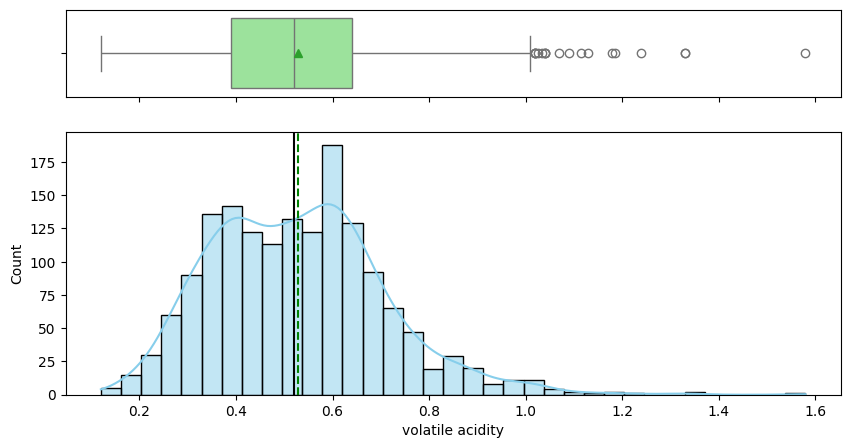

In [11]:
num_analysis_hist_box(data,'volatile acidity')

- *Volatile acidity has a fairly normal distribution with the mean and median equal to 0.5. There are few outliers*

#### Observations on citric acid

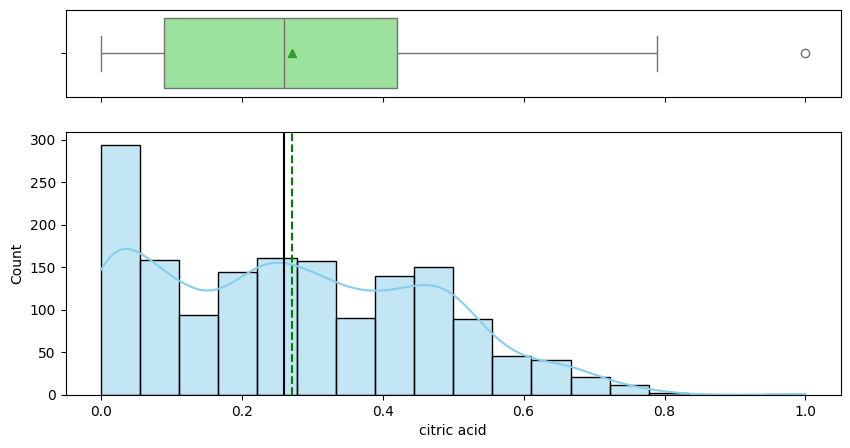

In [12]:
num_analysis_hist_box(data,'citric acid')

- *Citric acidity has a slightly right-skewed distribution with mean and median equal to 0.25.*

#### Observations on residual sugar

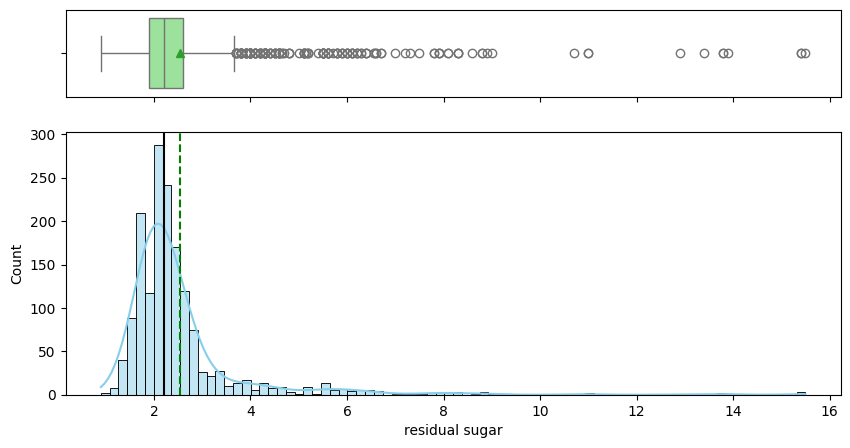

In [13]:
num_analysis_hist_box(data,'residual sugar')

- *The distribution of the variable is skewed to the right and there are many extreme values.* 

#### Observations on chlorides

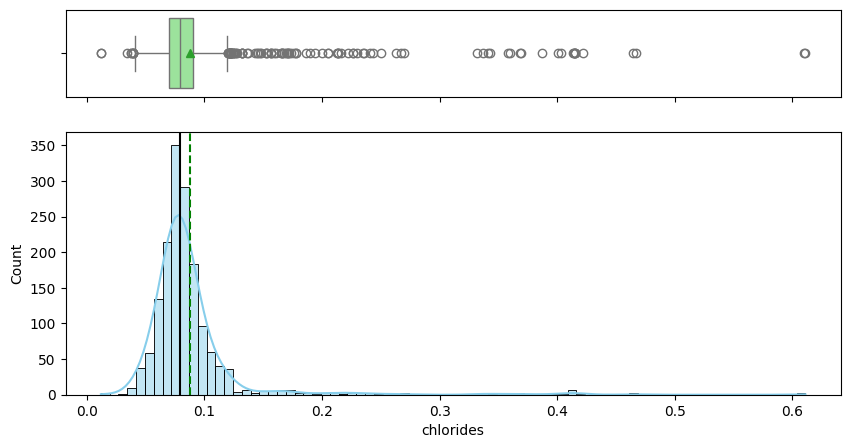

In [14]:
num_analysis_hist_box(data,'chlorides')

- *chlorides have a bell-shaped curve distribution with smaller spread.*

#### Observations on free sulfur dioxide

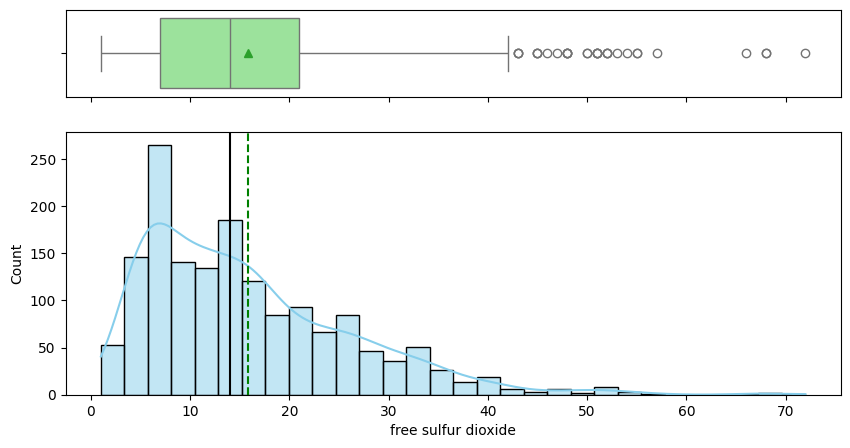

In [15]:
num_analysis_hist_box(data,'free sulfur dioxide')

- *The distribution of free sulfur dioxide is skewed to the right and have outliers on the right*

#### Observations on total sulfur dioxide

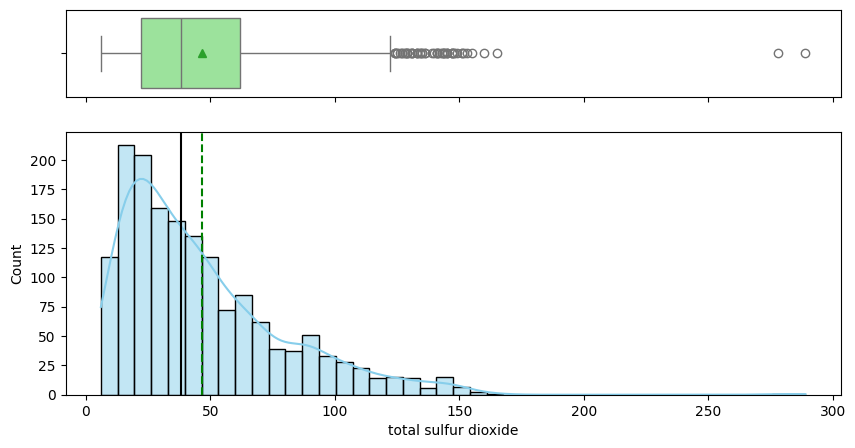

In [16]:
num_analysis_hist_box(data,'total sulfur dioxide')

- *The distribution of total sulfur dioxide concentration is right-skewed with many outliers.* 

#### Observations on density

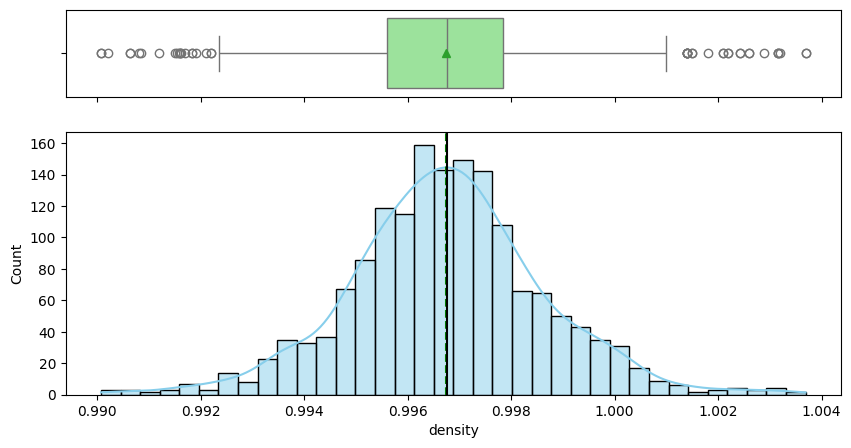

In [17]:
num_analysis_hist_box(data,'density')

- *The Distribution of density follows a normal distribution with mean and median almost equal*

#### Observations on pH

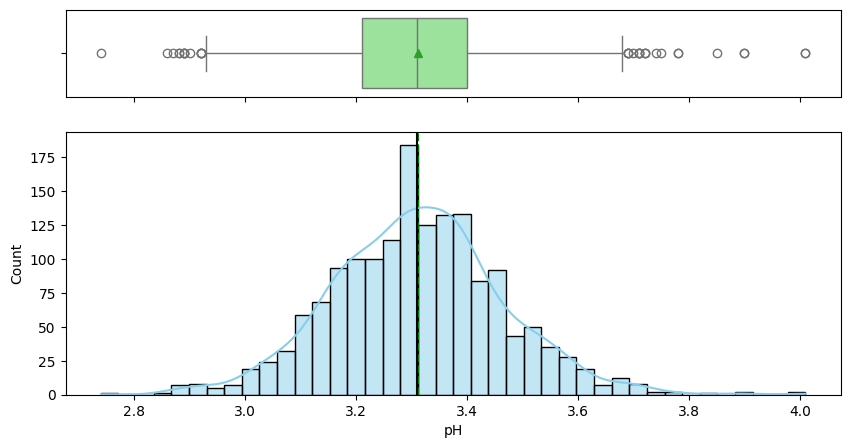

In [18]:
num_analysis_hist_box(data,'pH')

- *The distribution of pH looks normally distributed with mean and median equal to ~3.3, most wines have a pH value around 3.3 i.e. most wines are acidic.*

#### Observations on sulphates

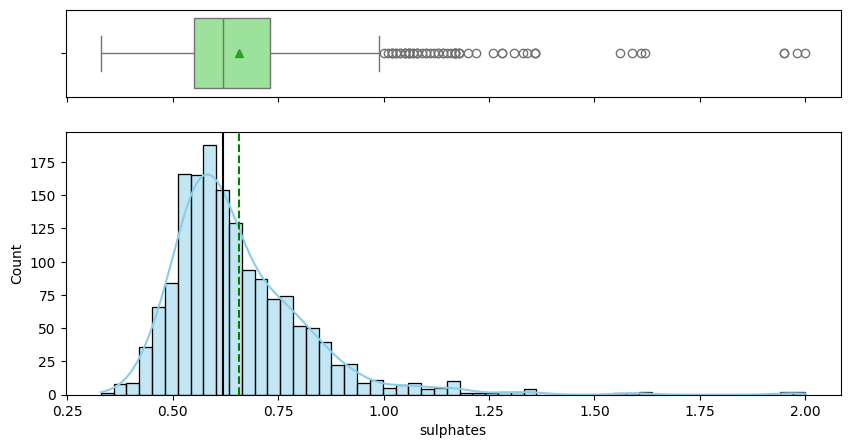

In [19]:
num_analysis_hist_box(data,'sulphates')

- *The distribution of sulphates, which act as antimicrobial and antioxidant in wines, is right-skewed and have several outliers towards the higher side*

#### Observations on alcohol

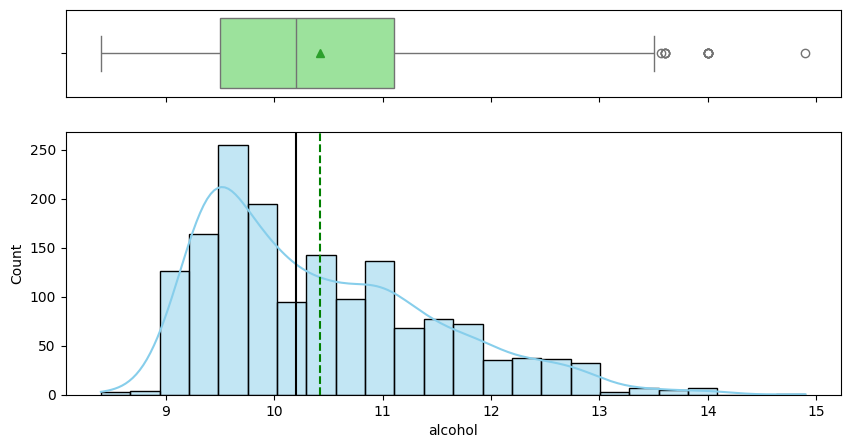

In [20]:
num_analysis_hist_box(data,'alcohol')

- *Most wines have 9% to 10% of alcohol. From the boxplot, we can see that there are some extreme values for wines having more than 13% of alcohol.*

In [21]:
# Function to plot count and percentage barplots side by side
def plot_count_and_percentage_barplot(data, column, figsize=(12, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

#### Observation on Quality

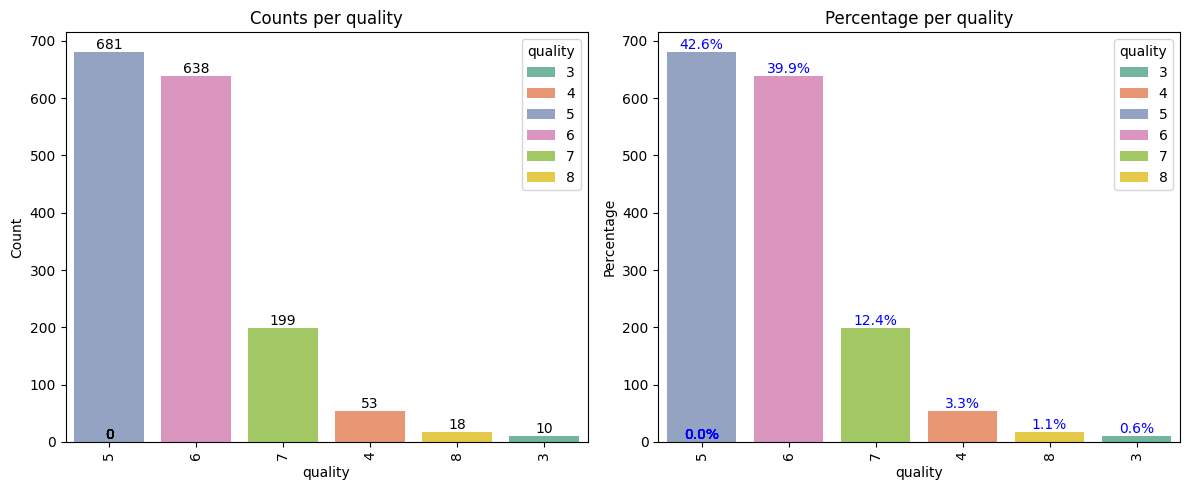

In [22]:
plot_count_and_percentage_barplot(data,"quality")

- *Most of the wines are rated either 5 or 6 and there are very few records for 3, 4, and 8 rated wines.*
- *The observations with 7 or 8 are very few. This might be because since these are high-quality premium wines with maximum rating.*
- *We can combine records to create two broad categories - premium quality wines and non-premium quality wines, where quality:  2-6 can be one class and quality: 7-8 can be the other class.*

In [23]:
data['quality_class'] = np.where(data['quality'] < 7, 'non-premium', 'premium')

In [24]:
data['quality_class'].value_counts()

quality_class
non-premium    1382
premium         217
Name: count, dtype: int64

- *We have reduced the number of categories to only two categories. The classes are imbalanced as there are only 217 observations with the premium class.*

#### Bivariate Analysis

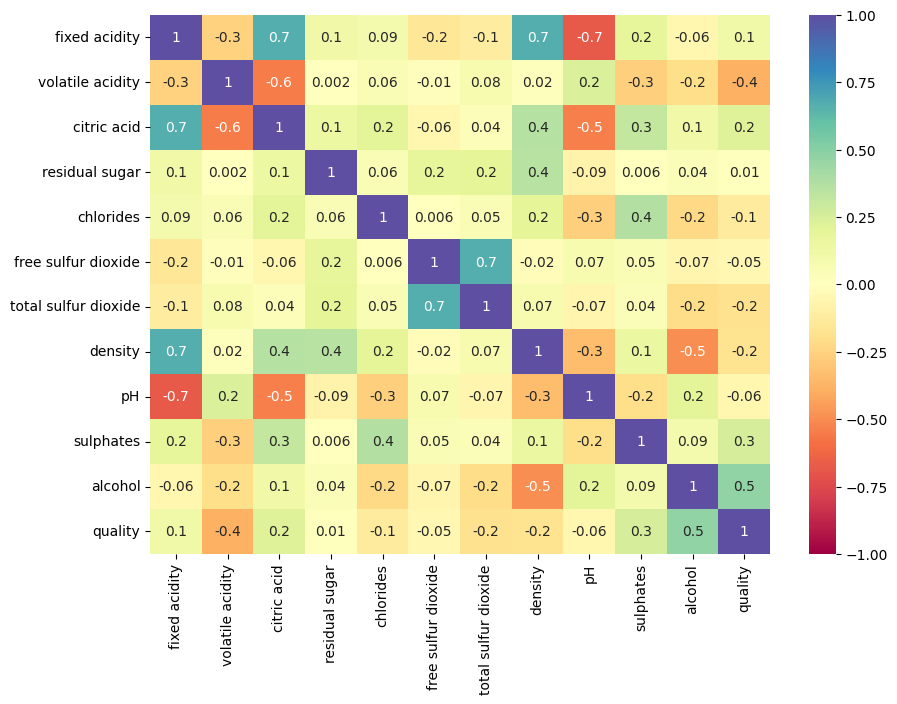

In [25]:
plt.figure(figsize=(10,7))
sns.heatmap(data.drop('quality_class', axis=1).corr(),annot=True,vmin=-1,vmax=1,fmt='.1g',cmap="Spectral")
plt.show()

- *Fixed acidity has a strong positive correlation with citric acid and density.*
- *The total sulfur dioxide and free sulfur dioxide have a strong correlation.*
- *The quality of wine shows a moderate correlation with alcohol.*

#### Quality vs acidity

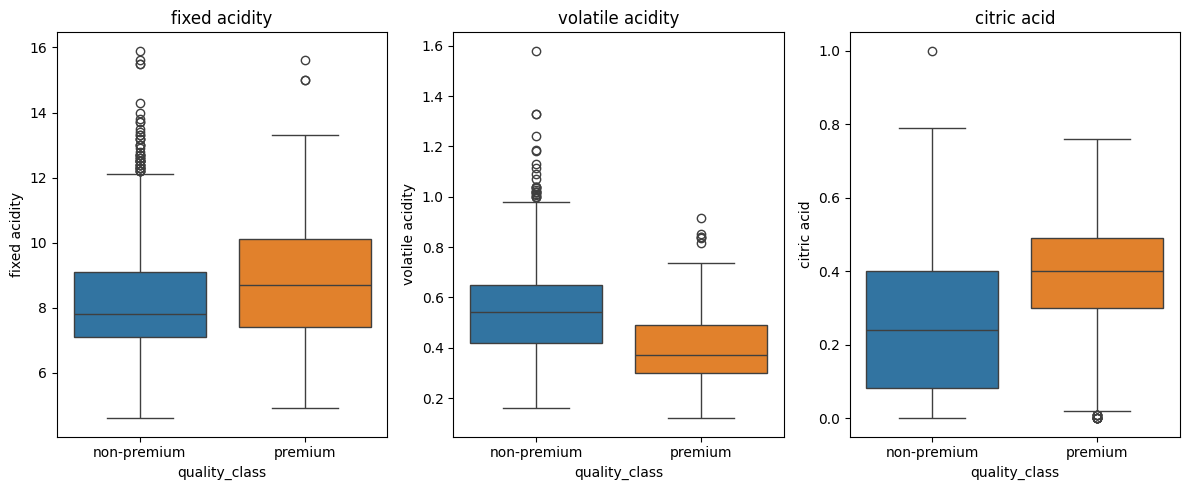

In [26]:
cols = data[['fixed acidity', 'volatile acidity', 'citric acid']].columns.tolist()
plt.figure(figsize=(12,5))

for i, variable in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=data, x= data['quality_class'],y = data[variable],hue='quality_class')
    plt.tight_layout()
    plt.title(variable)
plt.show()

*Premium wines have higher fixed acidity and citric acid and lower volatile acidity.*

#### Quality vs sulfur

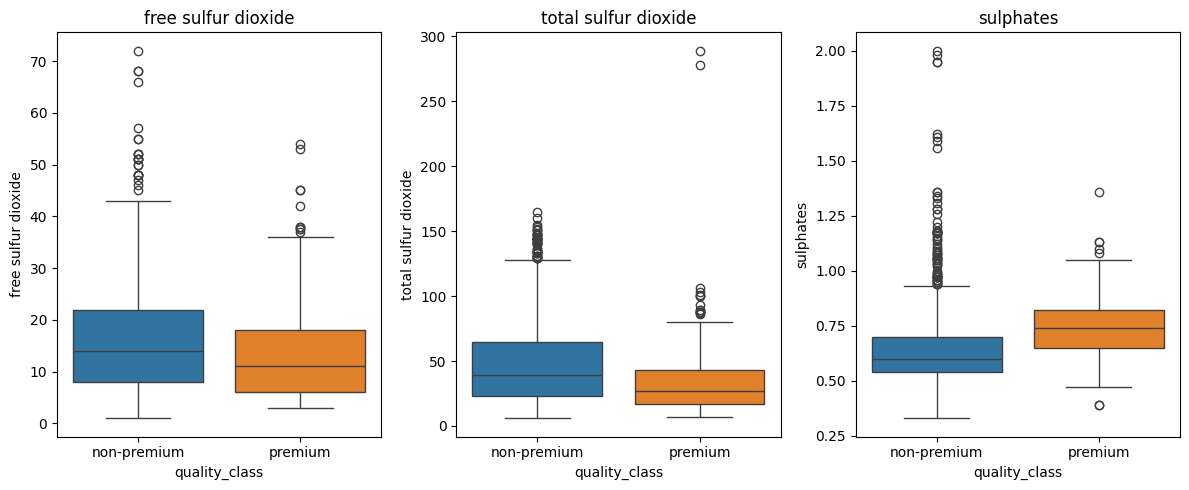

In [27]:
cols = data[['free sulfur dioxide', 'total sulfur dioxide', 'sulphates']].columns.tolist()
plt.figure(figsize=(12,5))

for i, variable in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=data, x= data['quality_class'],y = data[variable],hue='quality_class')
    plt.tight_layout()
    plt.title(variable)
plt.show()

*Premium wines have less concentration of free sulfur dioxide and total sulfur dioxide but higher suofates that helps in preserving them for a longer period.*

#### Quality vs chlorides

In [28]:
## function to plot boxplots w.rt quality
def boxplot(x_var):
    plt.figure(figsize=(7,5))
    sns.boxplot(data=data, x= data['quality_class'],y = x_var,hue='quality_class')
    plt.show()

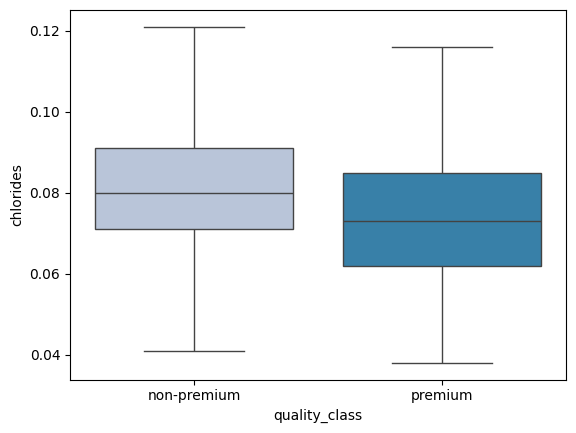

In [29]:
sns.boxplot(data=data, x=data['quality_class'], y=data['chlorides'], showfliers=False, palette='PuBu'); # not displaying outliers

*Premium wines have a lower concentration of chlorides in them.*

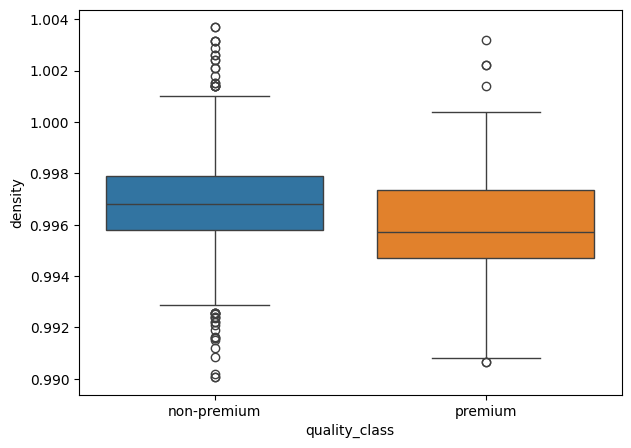

In [30]:
boxplot(data['density'])

*Premium wines have lesser density i.e. they have comparatively thinner than the non-premium wines.*

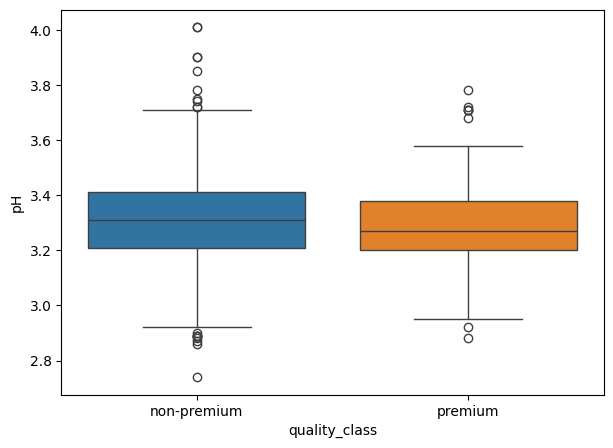

In [31]:
boxplot(data['pH'])

*Premium Wines have slightly less pH value*

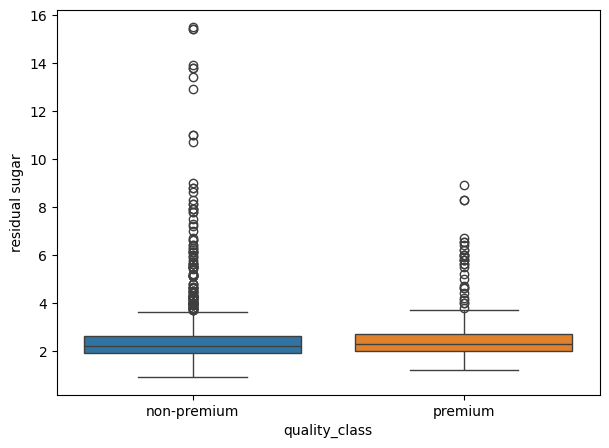

In [32]:
boxplot(data['residual sugar'])

*Both are similar*

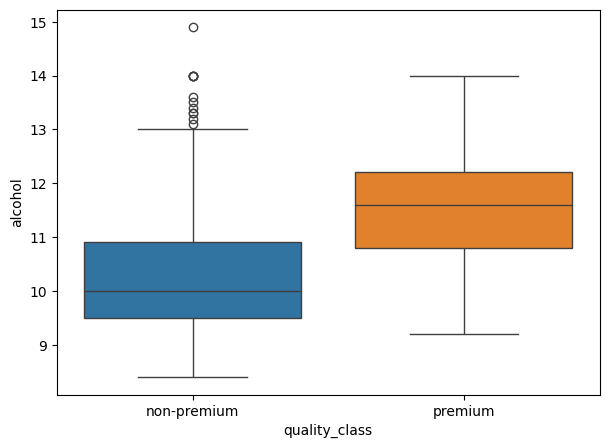

In [33]:
boxplot(data['alcohol'])

*Alcohol content plays a huge role in wine quality. We can see that premium wines have a higher alcohol content as compared to non-premium wines.*

### Data Preprocessing

#### Data Preparation for Modeling

In [34]:
data.drop('quality', axis=1, inplace=True)
X = data.drop('quality_class', axis=1)
y = data['quality_class'].apply(lambda x : 0 if x=='non-premium' else 1 )

In [35]:
# Splitting data into training and test set:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)
print(X_train.shape, X_test.shape)

(1119, 11) (480, 11)


In [36]:
y.value_counts(1)

quality_class
0    0.86429
1    0.13571
Name: proportion, dtype: float64

In [37]:
y_test.value_counts(1)

quality_class
0    0.864583
1    0.135417
Name: proportion, dtype: float64

### Model evaluation criterion


**The model can make wrong predictions as:**
1. Predicting a wine is of premium quality when it is of non-premium quality. False Positive
2. Predicting a wine is of non-premium quality when it is of premium quality. False Negative

**Which case is more important? **
1. If the model predicts a wine is of non-premium quality but it is of premium quality then the company would incur the loss of good wine and resources used.
2. If the model predicts a wine is of premium quality but it is not then the company would roll out low-quality wine which would affect their customer base and their reputation. 

**Which metric to optimize?**
* We would want F1-Score to be maximized, the greater the F1-Score higher the chances of predicting both the classes correctly.

**Helper Function**

In [38]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [39]:
# Confusion Matrix for classification
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='BuGn')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Decision Tree - Model Building and Hyperparameter Tuning

#### Decision Tree

ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy  Recall  Precision        F1
0    0.8875     0.6    0.58209  0.590909


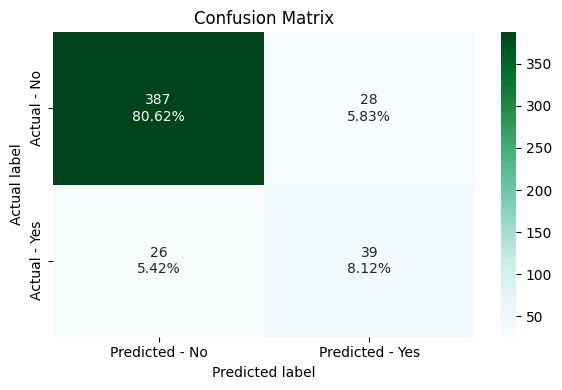

In [40]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

# Prints the parameters
for key, value in d_tree.get_params().items():
    print(f"{key}: {value}")

print()

#Calculating different metrics
d_tree_model_train_perf=model_performance_classification_sklearn(d_tree,X_train,y_train)
print("Training performance:\n",d_tree_model_train_perf)
d_tree_model_test_perf=model_performance_classification_sklearn(d_tree,X_test,y_test)
print("Testing performance:\n",d_tree_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(d_tree,X_test,y_test)

*The decision tree is overfitting the training data. Let's try hyperparameter tuning and see if the model performance improves.*

#### Decision Tree with Hyperparameter Tuning

In [41]:
#Choose the type of classifier. 
dtree_estimator = DecisionTreeClassifier(class_weight={0:0.18,1:0.72},random_state=1) # to handle class imbalance

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2,30), 
              'min_samples_leaf': [1, 2, 5, 7, 10],
              'max_leaf_nodes' : [2, 3, 5, 10,15],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
dtree_estimator.fit(X_train, y_train)

# Prints the parameters
for key, value in dtree_estimator.get_params().items():
    print(f"{key}: {value}")

ccp_alpha: 0.0
class_weight: {0: 0.18, 1: 0.72}
criterion: gini
max_depth: 4
max_features: None
max_leaf_nodes: 15
min_impurity_decrease: 0.0001
min_samples_leaf: 10
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best


Training performance:
    Accuracy    Recall  Precision   F1
0  0.853441  0.809211   0.476744  0.6
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.789583  0.707692   0.359375  0.476684


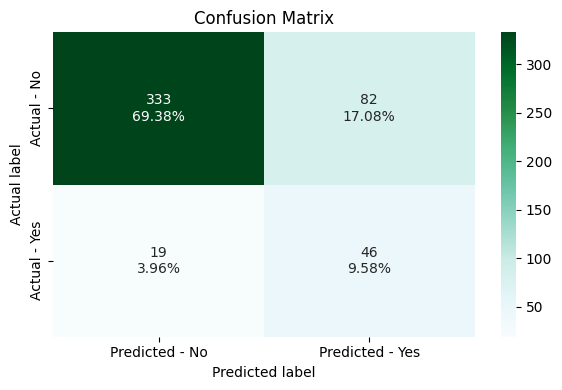

In [42]:
#Calculating different metrics
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator,X_train,y_train)
print("Training performance:\n",dtree_estimator_model_train_perf)
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator,X_test,y_test)
print("Testing performance:\n",dtree_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(dtree_estimator,X_test,y_test)

* The overfitting has reduced but the test f1-score has also decreased.
* Let's try some other models.

### Bagging - Model Building and Hyperparameter Tuning

#### Random Forest Classifier

bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 100
n_jobs: None
oob_score: False
random_state: 1
verbose: 0
warm_start: False

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.91875  0.492308   0.842105  0.621359


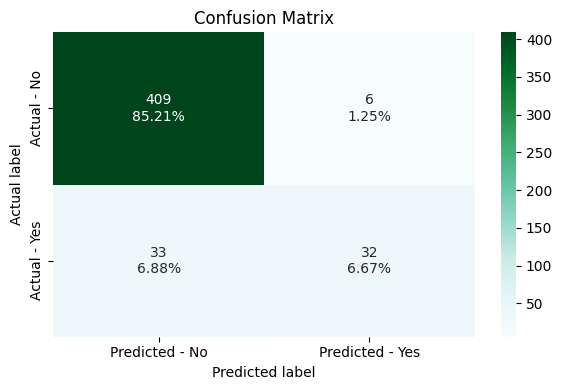

In [43]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

for key, value in rf_estimator.get_params().items():
    print(f"{key}: {value}")

print()
#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

*Random forest is giving a slightly higher test f1-score than decision trees but it is overfitting the training data. Let's try hyperparameter tuning and see if the model performance improves.*

#### Random Forest with Hyperparameter Tuning

In [44]:
# Choose the type of classifier. 
rf_tuned = RandomForestClassifier(class_weight={0:0.18,1:0.82},random_state=1,oob_score=True,bootstrap=True)

parameters = {  
                'max_depth': list(np.arange(5,30,5)) + [None],
                'max_features': ['sqrt','log2',None],
                'min_samples_leaf': np.arange(1,15,5),
                'min_samples_split': np.arange(2, 20, 5),
                'n_estimators': np.arange(10,110,10)}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
rf_tuned.fit(X_train, y_train)

for key, value in rf_tuned.get_params().items():
    print(f"{key}: {value}")

bootstrap: True
ccp_alpha: 0.0
class_weight: {0: 0.18, 1: 0.82}
criterion: gini
max_depth: 10
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 6
min_samples_split: 17
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 40
n_jobs: None
oob_score: True
random_state: 1
verbose: 0
warm_start: False


Training performance:
    Accuracy    Recall  Precision        F1
0  0.935657  0.881579   0.712766  0.788235
Testing performance:
    Accuracy    Recall  Precision        F1
0       0.9  0.723077    0.61039  0.661972


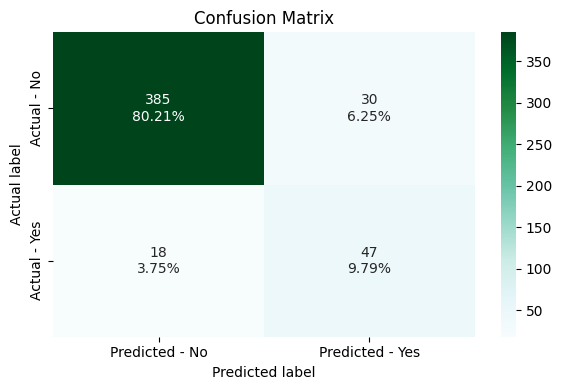

In [45]:
#Calculating different metrics
rf_tuned_model_train_perf=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train_perf)
rf_tuned_model_test_perf=model_performance_classification_sklearn(rf_tuned,X_test,y_test)
print("Testing performance:\n",rf_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned,X_test,y_test)

***The overfitting has reduced significantly and the model performance has improved. The test recall and test f1-score have increased.***

#### Bagging Classifier

   Accuracy  Recall  Precision        F1
0  0.983021   0.875        1.0  0.933333
   Accuracy    Recall  Precision        F1
0  0.916667  0.584615   0.745098  0.655172


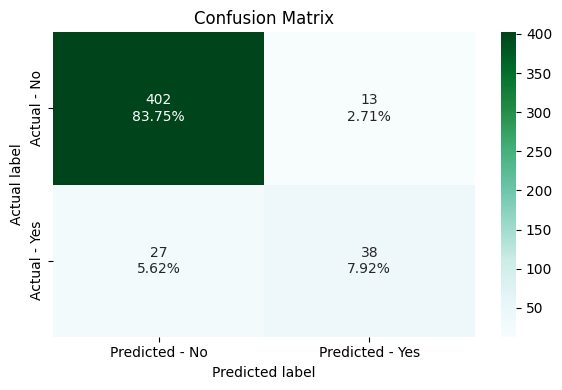

In [46]:
#Fitting the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train,y_train)

#Calculating different metrics
bagging_classifier_model_train_perf=model_performance_classification_sklearn(bagging_classifier,X_train,y_train)
print(bagging_classifier_model_train_perf)
bagging_classifier_model_test_perf=model_performance_classification_sklearn(bagging_classifier,X_test,y_test)
print(bagging_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(bagging_classifier,X_test,y_test)

*Bagging classifier is overfitting the training data. Let's try hyperparameter tuning and see if the model performance improves.*

#### Bagging Classifier with Hyperparameter Tuning

In [47]:
# Choose the type of classifier. 
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_samples': [0.7,0.8,0.9,1], 
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

for key, value in bagging_estimator_tuned.get_params().items():
    print(f"{key}: {value}")

bootstrap: True
bootstrap_features: False
estimator: None
max_features: 0.7
max_samples: 0.9
n_estimators: 50
n_jobs: None
oob_score: False
random_state: 1
verbose: 0
warm_start: False


   Accuracy    Recall  Precision      F1
0  0.999106  0.993421        1.0  0.9967
   Accuracy    Recall  Precision        F1
0   0.90625  0.461538       0.75  0.571429


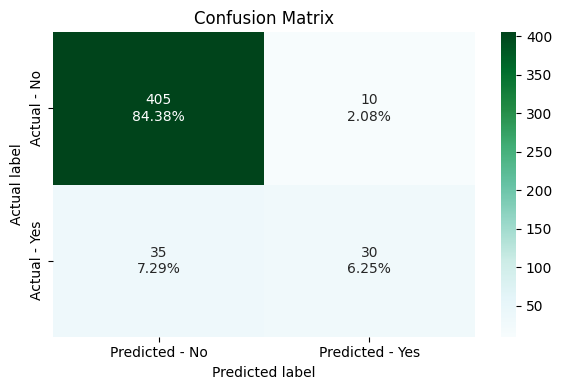

In [48]:
#Calculating different metrics
bagging_estimator_tuned_model_train_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_train,y_train)
print(bagging_estimator_tuned_model_train_perf)
bagging_estimator_tuned_model_test_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_test,y_test)
print(bagging_estimator_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(bagging_estimator_tuned,X_test,y_test)

* Surprisingly, the model performance has decreased after hyperparameter tuning.*

### Boosting - Model Building and Hyperparameter Tuning

#### AdaBoost Classifier

   Accuracy    Recall  Precision        F1
0  0.903485  0.453947   0.734043  0.560976
   Accuracy    Recall  Precision        F1
0  0.877083  0.338462   0.578947  0.427184


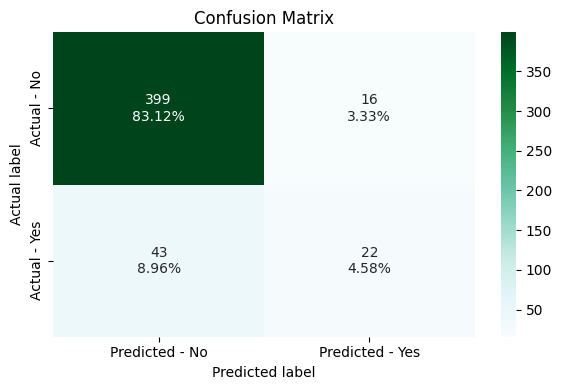

In [49]:
#Fitting the model
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train,y_train)

#Calculating different metrics
ab_classifier_model_train_perf=model_performance_classification_sklearn(ab_classifier,X_train,y_train)
print(ab_classifier_model_train_perf)
ab_classifier_model_test_perf=model_performance_classification_sklearn(ab_classifier,X_test,y_test)
print(ab_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(ab_classifier,X_test,y_test)

*Adaboost is giving more generalized performance than previous models but the test f1-score is too low.*

#### AdaBoost with Hyperparameter Tuning

In [50]:
# Choose the type of classifier. 
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    #Let's try different max_depth for base_estimator
    "estimator":[DecisionTreeClassifier(max_depth=1),DecisionTreeClassifier(max_depth=2),
                      DecisionTreeClassifier(max_depth=3)],
    "n_estimators": np.arange(10,110,10),
    "learning_rate":np.arange(0.1,2,0.1)
}

# Type of scoring used to compare parameter  combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

for key, value in abc_tuned.get_params().items():
    print(f"{key}: {value}")

algorithm: deprecated
estimator__ccp_alpha: 0.0
estimator__class_weight: None
estimator__criterion: gini
estimator__max_depth: 2
estimator__max_features: None
estimator__max_leaf_nodes: None
estimator__min_impurity_decrease: 0.0
estimator__min_samples_leaf: 1
estimator__min_samples_split: 2
estimator__min_weight_fraction_leaf: 0.0
estimator__monotonic_cst: None
estimator__random_state: None
estimator__splitter: best
estimator: DecisionTreeClassifier(max_depth=2)
learning_rate: 1.4000000000000001
n_estimators: 70
random_state: 1


   Accuracy    Recall  Precision        F1
0  0.971403  0.828947   0.954545  0.887324
   Accuracy    Recall  Precision        F1
0     0.875  0.415385    0.55102  0.473684


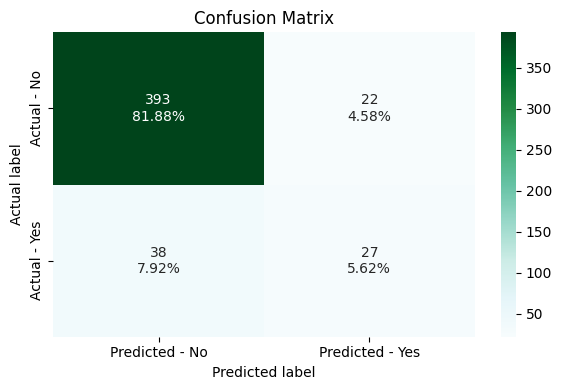

In [51]:
#Calculating different metrics
abc_tuned_model_train_perf=model_performance_classification_sklearn(abc_tuned,X_train,y_train)
print(abc_tuned_model_train_perf)
abc_tuned_model_test_perf=model_performance_classification_sklearn(abc_tuned,X_test,y_test)
print(abc_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(abc_tuned,X_test,y_test)

*The model performance has increased slightly but the model has started to overfit the training data.*

#### Gradient Boosting Classifier

Training performance:
    Accuracy    Recall  Precision     F1
0  0.969616  0.782895   0.991667  0.875
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.90625  0.492308   0.727273  0.587156


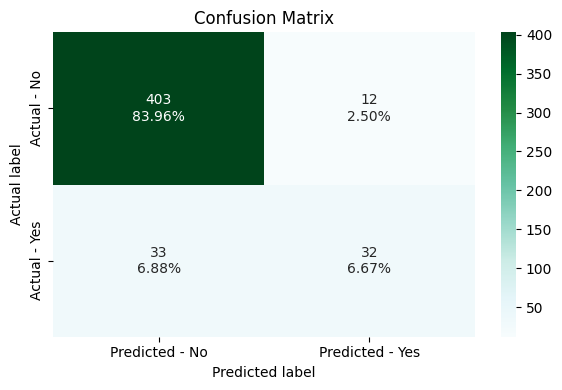

In [52]:
#Fitting the model
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train,y_train)

#Calculating different metrics
gb_classifier_model_train_perf=model_performance_classification_sklearn(gb_classifier,X_train,y_train)
print("Training performance:\n",gb_classifier_model_train_perf)
gb_classifier_model_test_perf=model_performance_classification_sklearn(gb_classifier,X_test,y_test)
print("Testing performance:\n",gb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(gb_classifier,X_test,y_test)

*The gradient boosting classifier is overfitting the training data.*

#### Gradient Boosting Hyperparameter Tuning

In [53]:
# Choose the type of classifier. 
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

for key, value in gbc_tuned.get_params().items():
    print(f"{key}: {value}")

ccp_alpha: 0.0
criterion: friedman_mse
init__algorithm: deprecated
init__estimator: None
init__learning_rate: 1.0
init__n_estimators: 50
init__random_state: 1
init: AdaBoostClassifier(random_state=1)
learning_rate: 0.1
loss: log_loss
max_depth: 3
max_features: 0.7
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
n_estimators: 250
n_iter_no_change: None
random_state: 1
subsample: 0.9
tol: 0.0001
validation_fraction: 0.1
verbose: 0
warm_start: False


Training performance:
    Accuracy    Recall  Precision        F1
0  0.993744  0.953947        1.0  0.976431
Testing performance:
    Accuracy    Recall  Precision       F1
0  0.908333  0.553846   0.705882  0.62069


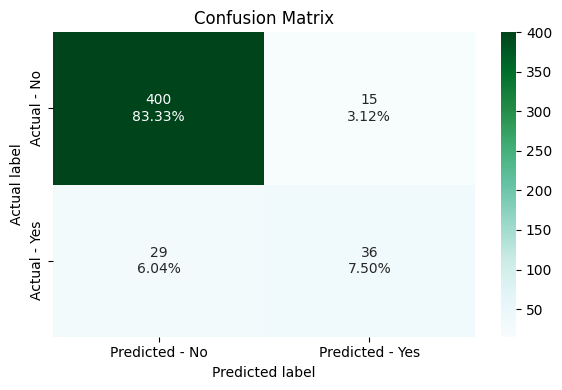

In [54]:
#Calculating different metrics
gbc_tuned_model_train_perf=model_performance_classification_sklearn(gbc_tuned,X_train,y_train)
print("Training performance:\n",gbc_tuned_model_train_perf)
gbc_tuned_model_test_perf=model_performance_classification_sklearn(gbc_tuned,X_test,y_test)
print("Testing performance:\n",gbc_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(gbc_tuned,X_test,y_test)

*There is not much difference in the model performance after hyperparameter tuning.*

#### XGBoost Classifier

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy  Recall  Precision        F1
0   0.91875     0.6       0.75  0.666667


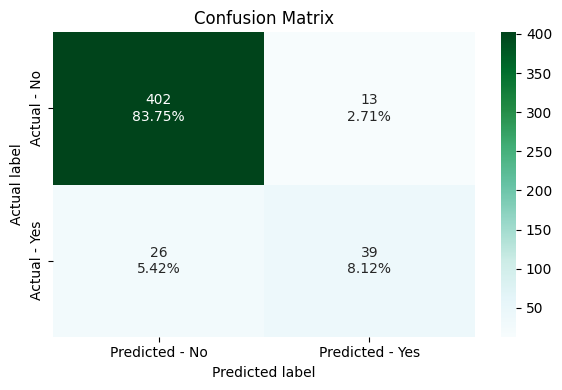

In [55]:
#Fitting the model
xgb_classifier = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_classifier.fit(X_train,y_train)

#Calculating different metrics
xgb_classifier_model_train_perf=model_performance_classification_sklearn(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)
xgb_classifier_model_test_perf=model_performance_classification_sklearn(xgb_classifier,X_test,y_test)
print("Testing performance:\n",xgb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_classifier,X_test,y_test)

*xgboost classifier is overfitting the training data.*

#### XGBoost with Hyperparameter Tuning

In [56]:
# Choose the type of classifier. 
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

# Grid of parameters to choose from
parameters = {
    "n_estimators": [10,30,50],
    "scale_pos_weight":[1,2,5],
    "subsample":[0.7,0.9,1],
    "learning_rate":[0.05, 0.1,0.2],
    "colsample_bytree":[0.7,0.9,1],
    "colsample_bylevel":[0.5,0.7,1]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

for key, value in xgb_tuned.get_params().items():
    print(f"{key}: {value}")

objective: binary:logistic
base_score: None
booster: None
callbacks: None
colsample_bylevel: 0.5
colsample_bynode: None
colsample_bytree: 0.9
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: logloss
feature_types: None
feature_weights: None
gamma: None
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: 0.1
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: None
max_leaves: None
min_child_weight: None
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: 50
n_jobs: None
num_parallel_tree: None
random_state: 1
reg_alpha: None
reg_lambda: None
sampling_method: None
scale_pos_weight: 5
subsample: 0.7
tree_method: None
validate_parameters: None
verbosity: None


Training performance:
    Accuracy    Recall  Precision        F1
0  0.971403  0.993421    0.82967  0.904192
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.89375  0.676923   0.594595  0.633094


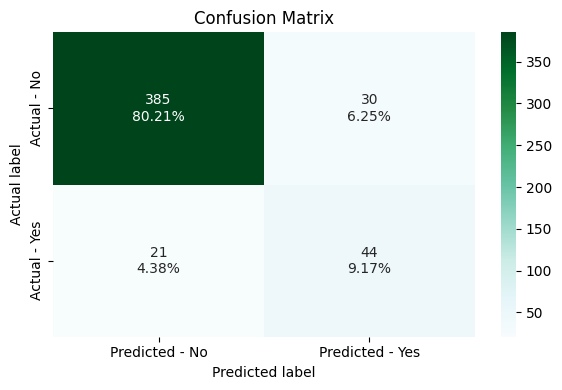

In [57]:
#Calculating different metrics
xgb_tuned_model_train_perf=model_performance_classification_sklearn(xgb_tuned,X_train,y_train)
print("Training performance:\n",xgb_tuned_model_train_perf)
xgb_tuned_model_test_perf=model_performance_classification_sklearn(xgb_tuned,X_test,y_test)
print("Testing performance:\n",xgb_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned,X_test,y_test)

*The overfitting has reduced slightly but there is not much difference in the model performance.*

### Stacking Model

In [58]:
estimators = [('Random Forest',rf_tuned), ('Gradient Boosting',gbc_tuned), ('Decision Tree',dtree_estimator)]

final_estimator = xgb_tuned

stacking_classifier= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

stacking_classifier.fit(X_train,y_train)

for key, value in stacking_classifier.get_params().items():
    print(f"{key}: {value}")

cv: None
estimators: [('Random Forest', RandomForestClassifier(class_weight={0: 0.18, 1: 0.82}, max_depth=np.int64(10),
                       min_samples_leaf=np.int64(6),
                       min_samples_split=np.int64(17),
                       n_estimators=np.int64(40), oob_score=True,
                       random_state=1)), ('Gradient Boosting', GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=250, random_state=1,
                           subsample=0.9)), ('Decision Tree', DecisionTreeClassifier(class_weight={0: 0.18, 1: 0.72}, max_depth=np.int64(4),
                       max_leaf_nodes=15, min_impurity_decrease=0.0001,
                       min_samples_leaf=10, random_state=1))]
final_estimator__objective: binary:logistic
final_estimator__base_score: None
final_estimator__booster: None
final_estimator__callbacks: None
final_estimator__colsample_bylevel: 0.5
final_estimator__colsample_bynode: None

Training performance:
    Accuracy    Recall  Precision        F1
0  0.930295  0.960526   0.669725  0.789189
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.839583  0.769231   0.446429  0.564972


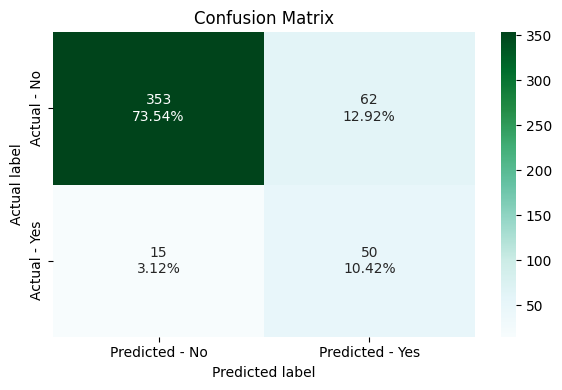

In [59]:
#Calculating different metrics
stacking_classifier_model_train_perf=model_performance_classification_sklearn(stacking_classifier,X_train,y_train)
print("Training performance:\n",stacking_classifier_model_train_perf)
stacking_classifier_model_test_perf=model_performance_classification_sklearn(stacking_classifier,X_test,y_test)
print("Testing performance:\n",stacking_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(stacking_classifier,X_test,y_test)

* The stacking classifier is giving a similar performance as compared to XGBoost with slightly less overfitting.*

### Comparing all models

In [60]:
# training performance comparison

models_train_comp_df = pd.concat(
    [d_tree_model_train_perf.T,dtree_estimator_model_train_perf.T,rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
     bagging_classifier_model_train_perf.T,bagging_estimator_tuned_model_train_perf.T,ab_classifier_model_train_perf.T,
     abc_tuned_model_train_perf.T,gb_classifier_model_train_perf.T,gbc_tuned_model_train_perf.T,xgb_classifier_model_train_perf.T,
    xgb_tuned_model_train_perf.T,stacking_classifier_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree,1.000000,1.000000,1.000000,1.000000
Decision Tree Estimator,0.853441,0.809211,0.476744,0.600000
Random Forest Estimator,1.000000,1.000000,1.000000,1.000000
Random Forest Tuned,0.935657,0.881579,0.712766,0.788235
Bagging Classifier,0.983021,0.875000,1.000000,0.933333
Bagging Estimator Tuned,0.999106,0.993421,1.000000,0.996700
Adaboost Classifier,0.903485,0.453947,0.734043,0.560976
Adabosst Classifier Tuned,0.971403,0.828947,0.954545,0.887324
Gradient Boost Classifier,0.969616,0.782895,0.991667,0.875000
Gradient Boost Classifier Tuned,0.993744,0.953947,1.000000,0.976431


In [61]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [d_tree_model_test_perf.T,dtree_estimator_model_test_perf.T,rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
     bagging_classifier_model_test_perf.T,bagging_estimator_tuned_model_test_perf.T,ab_classifier_model_test_perf.T,
     abc_tuned_model_test_perf.T,gb_classifier_model_test_perf.T,gbc_tuned_model_test_perf.T,xgb_classifier_model_test_perf.T,
    xgb_tuned_model_test_perf.T,stacking_classifier_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Testing performance comparison:")
models_test_comp_df.T

Testing performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree,0.887500,0.600000,0.582090,0.590909
Decision Tree Estimator,0.789583,0.707692,0.359375,0.476684
Random Forest Estimator,0.918750,0.492308,0.842105,0.621359
Random Forest Tuned,0.900000,0.723077,0.610390,0.661972
Bagging Classifier,0.916667,0.584615,0.745098,0.655172
Bagging Estimator Tuned,0.906250,0.461538,0.750000,0.571429
Adaboost Classifier,0.877083,0.338462,0.578947,0.427184
Adabosst Classifier Tuned,0.875000,0.415385,0.551020,0.473684
Gradient Boost Classifier,0.906250,0.492308,0.727273,0.587156
Gradient Boost Classifier Tuned,0.908333,0.553846,0.705882,0.620690


- *The majority of the models are overfitting the training data in terms of f1-score.*
- *The bagging classifier is giving the highest f1-score on the test data but is overfitting the training data.*
- *The tuned random forest has given the second-highest test f1-score and is giving a more generalized performance as compared to the bagging classifier.*

### Feature importance of Tuned Random Forest

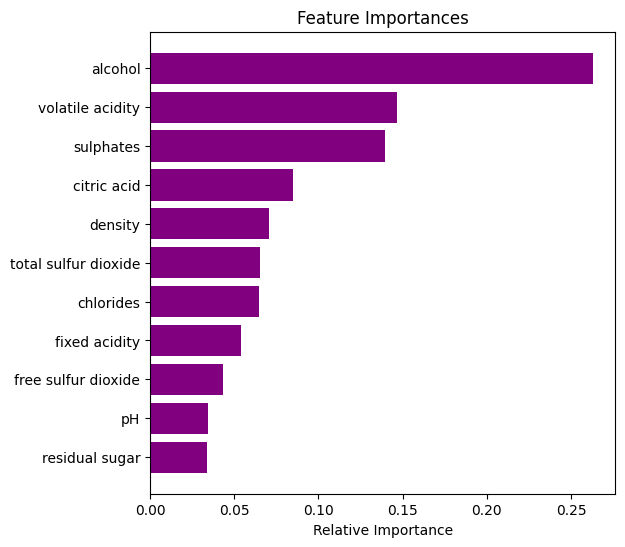

In [62]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

*Alcohol is the most important feature in identifying premium quality wine followed by sulfates and volatile acidity.*